In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
from langchain_groq import ChatGroq
# model=ChatGroq(model="qwen/qwen3.6-27b")
model=ChatGroq(model="openai/gpt-oss-120b")
print(model)
# print("hello world")

metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}} profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True} client=<groq.resources.chat.completions.Completions object at 0x000001B7761D0590> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B7761D12B0> model_name='openai/gpt-oss-120b' model_kwargs={} groq_api_key=SecretStr('**********')


In [2]:
from pydantic import BaseModel, Field
# node to fetch latest trending vide from the youtube using API.

import requests
def fetch_trending_video(state):
    video_id=state["video_id"]
    print("fetch trending video node called")
    # res= requests.get("https://abcd.com/")
    # data=res.json()
    # This is the data of that trending video
    data={
        "title":"US Iran War: ईरान पर अमेरिका की ताबड़तोड़ कार्रवाई! ट्रंप बोले- रडार और नौसैनिक ढांचा तबाह | AajTak",
        "channelTitle":"Aajtak",
        "tags":["usiranwar" ,"usattack ","trump ","atwebvideos ","aajtak  ","aajtakdigital" ,"tvchunks"],
        "description":"""ईरान और अमेरिका के बीच तनाव लगातार बढ़ता जा रहा है। अमेरिकी राष्ट्रपति डोनाल्ड ट्रंप ने दावा किया है कि अमेरिकी सेना ने ईरान के रडार और नौसैनिक ढांचे पर बेहद भारी हमले किए हैं। वहीं ईरान की ओर से अमेरिकी हमलों में एक शादी समारोह को निशाना बनाए जाने और बड़ी संख्या में लोगों के हताहत होने का दावा किया गया है।

इस बीच ईरान ने अमेरिकी MQ-9 रीपर ड्रोन को मार गिराने का दावा किया है। आर्थिक मोर्चे पर भी दबाव बढ़ रहा है, जबकि SCO सम्मेलन के दौरान पीएम मोदी और ईरानी राष्ट्रपति मसूद पेज़ेश्कियान की मुलाकात के बाद अमेरिका की ओर से ईरान की आर्थिक मदद या प्रतिबंधों को दरकिनार करने वाले देशों को चेतावनी दी गई है। आखिर ईरान-अमेरिका की इस जंग का अगला मोड़ क्या होगा? 
"""
        

    }
    required_data={}
    required_data["title"]=data["title"]
    required_data["description"]=data["description"]
    required_data["channelTitle"]=data["channelTitle"]
    required_data["tags"]=data["tags"]
    print("result of fetch trending vide node:",required_data)
    return {"refrence_video":required_data}
                


In [3]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from graph.prompts import RESEARCH_AGENT_SYSTEM_MESSAGE, RESEARCH_AGENT_SYSTEM_MESSAGE_TO_STRUCTURE
from datetime import datetime
from graph.tools import tavily_search_tool
from graph.schemas import  ReleventVideos

def research_agent(state):
    """Researches trending updates and returns 1 validated, structured video concepts."""
    refrence_video = state["refrence_video"]
    current_date=datetime.now()

    # 1. Agent System Prompt: Guides web search & analysis
    agent_system_message = RESEARCH_AGENT_SYSTEM_MESSAGE.format(
        current_date=current_date,
        refrence_video_title=refrence_video.get("title", ""),
        refrence_video_channel_title=refrence_video.get("channelTitle", ""),
        refrence_video_description=refrence_video.get("description", ""),
        refrence_video_tags=refrence_video.get("tags", "")
        )
    agent = create_agent(
        model=model,
        tools=[tavily_search_tool],
        system_prompt=agent_system_message,
    )
    print("here agent decleration ended and agent invocation happen")
    agent_res = agent.invoke({
        "messages": [{
            "role": "user", 
            "content": "Research the latest facts and real-time updates for this video topic. Formulate 1 distinct video angles.",
            
        }]
    })
    print("here agent invocation has ended")
    agent_message = agent_res["messages"][-1].content

    # 2. Structured Output Prompt: Injects the agent's verified research

    structured_output_prompt = ChatPromptTemplate.from_messages([
        ("system", RESEARCH_AGENT_SYSTEM_MESSAGE_TO_STRUCTURE),
        (
            "human",
            """Below is the verified research report on this topic:

---
{research_data}
---

Generate the 1 structured video concept based on this verified research."""
        ),
    ])

    model_with_structured_output = model.with_structured_output(ReleventVideos)
    chain = structured_output_prompt | model_with_structured_output

    # 3. Invoke chain with reference metadata and research data
    result = chain.invoke({
        "ref_title": refrence_video.get("title", ""),
        "ref_channel": refrence_video.get("channelTitle", ""),
        "ref_desc": refrence_video.get("description", ""),
        "research_data": agent_message,
    })
    return {"relevent_videos":result.videos}

In [4]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from graph.prompts import FINAL_YOUTUBE_CONTENT_SYSTEM_PROMPT, FINAL_YOUTUBE_CONTENT_HUMAN_PROMPT
from graph.schemas import GeneratedVideoData


def finalize_youtube_content(state):
    relevent_videos=state["relevent_videos"]
    inputs=[{"title":video.title if hasattr(video,"title") else video["title"],
             "summary":video.summary if hasattr(video,"summary") else video["summary"],
             "viewer_hook":video.viewer_hook if hasattr(video,"viewer_hook") else video["viewer_hook"]
             } for video in relevent_videos]

    prompt = ChatPromptTemplate.from_messages([
        ("system", FINAL_YOUTUBE_CONTENT_SYSTEM_PROMPT),
        ("human", FINAL_YOUTUBE_CONTENT_HUMAN_PROMPT),
    ])
    structured_model = model.with_structured_output(GeneratedVideoData)
    chain = prompt | structured_model
    final_video_data=chain.batch(inputs)
    print("here is the final_video data:",final_video_data)
    # return final_video_data
    return {"final_video_data":final_video_data}

In [5]:
from graph.tools import generate_thumb_image



def generate_thumbnail(state):
    final_video_data=state["final_video_data"]
    inputs=[{"title":video.title,"description":video.description} for video in final_video_data]
    thumbnails=generate_thumb_image.batch(inputs)
    print("here are all the thumbnails==>",thumbnails)
    combined_videos = [
        {
            **video.model_dump(),     # Unpacks title, description, tags, etc.
            "thumb_image": thumb      # Adds the thumbnail result
        }
        for video, thumb in zip(final_video_data, thumbnails)
    ]
    
    print("Combined video package:", combined_videos)
    return {"final_video_package": combined_videos}

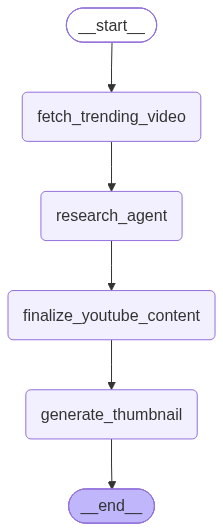

In [7]:
from langgraph.graph import StateGraph, START,END
from IPython.display import display, Image
from graph.schemas import State
builder=StateGraph(State)

builder.add_node("fetch_trending_video",fetch_trending_video)
builder.add_node("research_agent",research_agent)
builder.add_node("finalize_youtube_content",finalize_youtube_content)
builder.add_node("generate_thumbnail",generate_thumbnail)

builder.add_edge(START, "fetch_trending_video")
builder.add_edge("fetch_trending_video","research_agent")
builder.add_edge("research_agent","finalize_youtube_content")
builder.add_edge("finalize_youtube_content","generate_thumbnail")
builder.add_edge("generate_thumbnail",END)
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
res = graph.invoke(
    {"video_id": "abcd"},
    {"recursion_limit": 10}
)

fetch trending video node called
result of fetch trending vide node: {'title': 'US Iran War: ईरान पर अमेरिका की ताबड़तोड़ कार्रवाई! ट्रंप बोले- रडार और नौसैनिक ढांचा तबाह | AajTak', 'description': 'ईरान और अमेरिका के बीच तनाव लगातार बढ़ता जा रहा है। अमेरिकी राष्ट्रपति डोनाल्ड ट्रंप ने दावा किया है कि अमेरिकी सेना ने ईरान के रडार और नौसैनिक ढांचे पर बेहद भारी हमले किए हैं। वहीं ईरान की ओर से अमेरिकी हमलों में एक शादी समारोह को निशाना बनाए जाने और बड़ी संख्या में लोगों के हताहत होने का दावा किया गया है।\n\nइस बीच ईरान ने अमेरिकी MQ-9 रीपर ड्रोन को मार गिराने का दावा किया है। आर्थिक मोर्चे पर भी दबाव बढ़ रहा है, जबकि SCO सम्मेलन के दौरान पीएम मोदी और ईरानी राष्ट्रपति मसूद पेज़ेश्कियान की मुलाकात के बाद अमेरिका की ओर से ईरान की आर्थिक मदद या प्रतिबंधों को दरकिनार करने वाले देशों को चेतावनी दी गई है। आखिर ईरान-अमेरिका की इस जंग का अगला मोड़ क्या होगा? \n', 'channelTitle': 'Aajtak', 'tags': ['usiranwar', 'usattack ', 'trump ', 'atwebvideos ', 'aajtak  ', 'aajtakdigital', 'tvchunks']}
here ag

In [ ]:
res["final_video_package"]

[{'title': 'US‑Iran 2026 War: Radar Strike Sends Oil to $95/barrel – Full Fallout',
  'description': 'If you thought the US‑Iran clash was just another missile exchange, think again – a single radar strike sent oil to $95/barrel and a wedding hall became a battlefield. Discover the full military, human and market fallout that could reshape the Gulf forever.\n\nIn this deep‑dive we break down:\n0:00 Intro – Why this war matters\n1:15 U.S. kinetic phase: radar and naval strikes\n3:40 Iran’s claim: MQ‑9 downed over a wedding crowd\n6:05 Civilian casualties & U.S. soldier losses\n8:20 Oil‑price shock: markets react to $95/barrel\n10:45 Diplomatic ripple: SCO summit, India‑Iran talks, U.S. secondary‑sanctions\n13:30 Future outlook: low‑intensity conflict & Gulf power shift\n\nAnimated maps, split‑screen drone footage, real‑time oil tickers, and concise infographics bring the story to life.\n\n#USIranWar #OilPriceShock #MiddleEastConflict #Geopolitics #MilitaryAnalysis',
  'tags': ['US Iran 